# **Klasifikasi Status Persetujuan | K - Nearest Neighbours**

Perusahaan Dream Housing ingin mengoptimasi proses kelayakan pinjaman secara real-time dengan model machine learning prediksi klasifikasi status persetujuan kredit atau peminjaman rumah menggunakan model K - Nearest Neighbours. 

## 1. Data Understanding 

### 1.1 Import Library

In [287]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tkinter as tk

from tkinter import messagebox

### 1.2 Read Dataset 

In [288]:
# Load 'loan-train.csv' & 'loant-test.csv' dataset
loan_train = pd.read_csv('loan-train.csv')
loan_test = pd.read_csv('loan-test.csv')

In [289]:
# Show the top 5 rows of data train
print('\n5 top rows of data train:')
loan_train.head()


5 top rows of data train:


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [290]:
# Show the top 5 rows of data test 
print('\n5 top rows of data test:')
loan_test.head()


5 top rows of data test:


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,LP001015,Male,Yes,0,Graduate,No,5720,0,110.0,360.0,1.0,Urban
1,LP001022,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0,1.0,Urban
2,LP001031,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0,1.0,Urban
3,LP001035,Male,Yes,2,Graduate,No,2340,2546,100.0,360.0,NaN,Urban
4,LP001051,Male,No,0,Not Graduate,No,3276,0,78.0,360.0,1.0,Urban


In [291]:
# show the data train information
print('\nData train information:')
loan_train.info()


Data train information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


- `Loan_ID`             : ID unik untuk setiap pengajuan pinjaman
- `Gender`              : Jenis kelamin pemohon (Male/Female)
- `Married`             : Status pernikahan pemohon (Y = Menikah, N = Belum menikah)
- `Dependents`          : Jumlah tanggungan keluarga pemohon
- `Education`           : Tingkat pendidikan terakhir (Graduate/Under Graduate)
- `Self_Employed`       : Status pekerjaan mandiri/wiraswasta (Y/N)
- `ApplicantIncome`     : Pendapatan utama pemohon
- `CoapplicantIncome`   : Pendapatan tambahan dari pasangan/penjamin
- `LoanAmount`          : Jumlah pinjaman yang diajukan (dalam ribuan)
- `Loan_Amount_Term`    : Jangka waktu pelunasan pinjaman (bulan)
- `Credit_History`      : Riwayat kredit pemohon (1 = baik/lancar, 0 = buruk)
- `Property_Area`       : Lokasi properti (Urban/Semi-Urban/Rural)
- `Loan_Status`         : Status persetujuan pinjaman (Y = disetujui, N = ditolak)

In [293]:
# Show the number of unique values per columns
print('\nNumber of Unique Values in training data:')
loan_train.nunique()


Number of Unique Values in training data:


Loan_ID              614
Gender                 2
Married                2
Dependents             4
Education              2
Self_Employed          2
ApplicantIncome      505
CoapplicantIncome    287
LoanAmount           203
Loan_Amount_Term      10
Credit_History         2
Property_Area          3
Loan_Status            2
dtype: int64

The 'Loan_ID' column contains unique values for each row and does not contribute useful information for prediction. Therefore, it will be removed from the dataset.

In [294]:
# Drop the 'Loan_ID' column
loan_train = loan_train.drop('Loan_ID', axis=1)

In [295]:
# show the training columns after dropping the 'Loan_ID' columns
loan_train.columns

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

In [296]:
# show the dimensional data
print('\nShape of Data train:')
print('Number of rows:', loan_train.shape[0])
print('Number of columns:', loan_train.shape[1])

print('\nShape of Data test:')
print('Number of rows:', loan_test.shape[0])
print('Number of columns:', loan_test.shape[1])



Shape of Data train:
Number of rows: 614
Number of columns: 12

Shape of Data test:
Number of rows: 367
Number of columns: 12


In [297]:
# Separate Categorical & Numerical Columns 
num_cols = loan_train.select_dtypes(include=['int64', 'float64'])
cat_cols = loan_train.select_dtypes(include=['object', 'category'])

In [298]:
# Show the datatypes of num_cum cols & cat_cols
print('\nNumerical Columns:')
print(num_cols.dtypes)

print('\nCategorical Columns:')
print(cat_cols.dtypes)


Numerical Columns:
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
dtype: object

Categorical Columns:
Gender           object
Married          object
Dependents       object
Education        object
Self_Employed    object
Property_Area    object
Loan_Status      object
dtype: object


In [299]:
# Show number of missing values
print("\nNumber of Missing Value in training dataset:", loan_train.isnull().sum().sum())


Number of Missing Value in training dataset: 149


In [300]:
# Show the rows with missing values
print('\nRows with Missing Values:')
loan_train[loan_train.isnull().any(axis=1)]


Rows with Missing Values:


,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
11,Male,Yes,2,Graduate,NaN,2500,1840.0,109.0,360.0,1.0,Urban,Y
16,Male,No,1,Not Graduate,No,3596,0.0,100.0,240.0,NaN,Urban,Y
19,Male,Yes,0,Graduate,NaN,2600,3500.0,115.0,NaN,1.0,Urban,Y
23,NaN,Yes,2,Not Graduate,No,3365,1917.0,112.0,360.0,0.0,Rural,N
...,...,...,...,...,...,...,...,...,...,...,...,...
592,NaN,No,3+,Graduate,Yes,9357,0.0,292.0,360.0,1.0,Semiurban,Y
597,Male,No,NaN,Graduate,No,2987,0.0,88.0,360.0,0.0,Semiurban,N
600,Female,No,3+,Graduate,NaN,416,41667.0,350.0,180.0,NaN,Urban,N
601,Male,Yes,0,Not Graduate,NaN,2894,2792.0,155.0,360.0,1.0,Rural,Y


In [301]:
# Show number of missing values in numerical & categorical columns
print('\nNumber of missing values in numerical columns:', num_cols.isnull().sum().sum())
print('\nNumber of missing values in categorical columns:', cat_cols.isnull().sum().sum())


Number of missing values in numerical columns: 86

Number of missing values in categorical columns: 63


In [302]:
# Show number of missing values in numerical & categorical columns
print('\nNumber of missing values in numerical columns:\n', num_cols.isnull().sum())
print('\nNumber of missing values in categorical columns:\n', cat_cols.isnull().sum())


Number of missing values in numerical columns:
 ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
dtype: int64

Number of missing values in categorical columns:
 Gender           13
Married           3
Dependents       15
Education         0
Self_Employed    32
Property_Area     0
Loan_Status       0
dtype: int64


In [303]:
# Show the number of data duplicated in training dataset 
print('\nNumber of data duplicated in training dataset:', loan_train.duplicated().sum())


Number of data duplicated in training dataset: 0


In [304]:
# Loop for showing unique values 
for col in cat_cols:
    print(f'\nFeature: {col}')
    print('Number of Unique Values:', loan_train[col].nunique())
    print('Unique Values:', loan_train[col].unique())


Feature: Gender
Number of Unique Values: 2
Unique Values: ['Male' 'Female' nan]

Feature: Married
Number of Unique Values: 2
Unique Values: ['No' 'Yes' nan]

Feature: Dependents
Number of Unique Values: 4
Unique Values: ['0' '1' '2' '3+' nan]

Feature: Education
Number of Unique Values: 2
Unique Values: ['Graduate' 'Not Graduate']

Feature: Self_Employed
Number of Unique Values: 2
Unique Values: ['No' 'Yes' nan]

Feature: Property_Area
Number of Unique Values: 3
Unique Values: ['Urban' 'Rural' 'Semiurban']

Feature: Loan_Status
Number of Unique Values: 2
Unique Values: ['Y' 'N']


## 2. Exploratory Data Analysis

### 2.1 Multivariate Analysis

In [305]:
# Show the statistical summary of Dataset 
print('\nStatistical Summary of numerical columns:')
num_cols.describe()


Statistical Summary of numerical columns:


,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


From the statistical summary above, we can conclude that most feature have a large standart deviation (without Credit_History), and the different of median and maximum values is relatively high. Which may have outliers.

In [306]:
# Show statistical sumamary of categorical colums 
print('\nStatistical Summary of Categorical Columns:')
cat_cols.describe()


Statistical Summary of Categorical Columns:


,Gender,Married,Dependents,Education,Self_Employed,Property_Area,Loan_Status
count,601,611,599,614,582,614,614
unique,2,2,4,2,2,3,2
top,Male,Yes,0,Graduate,No,Semiurban,Y
freq,489,398,345,480,500,233,422


Based from statistical summary above, applicans are male, married, no dependents, graduate, and not self_employed. Majority live in Semiruban. Most applications were approved.

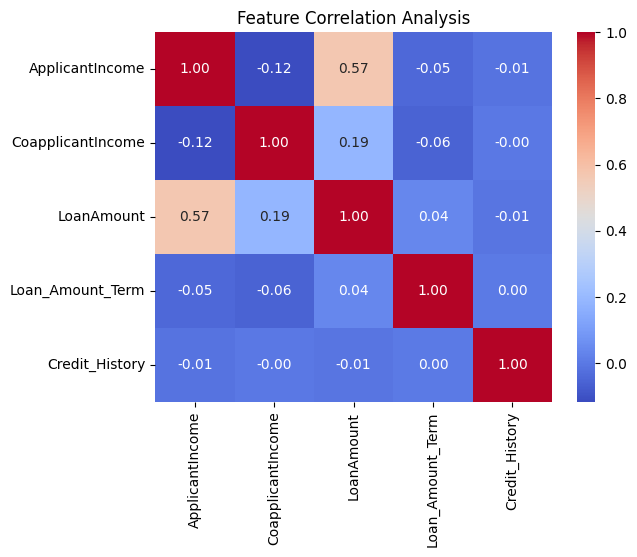

In [307]:
# Show the correlation between features
correlation = num_cols.corr()

# Heatmap
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Analysis')
plt.show()

From correlation analysis above, we can conclude that none of the features have a high correlation. This means there has no redundant features.

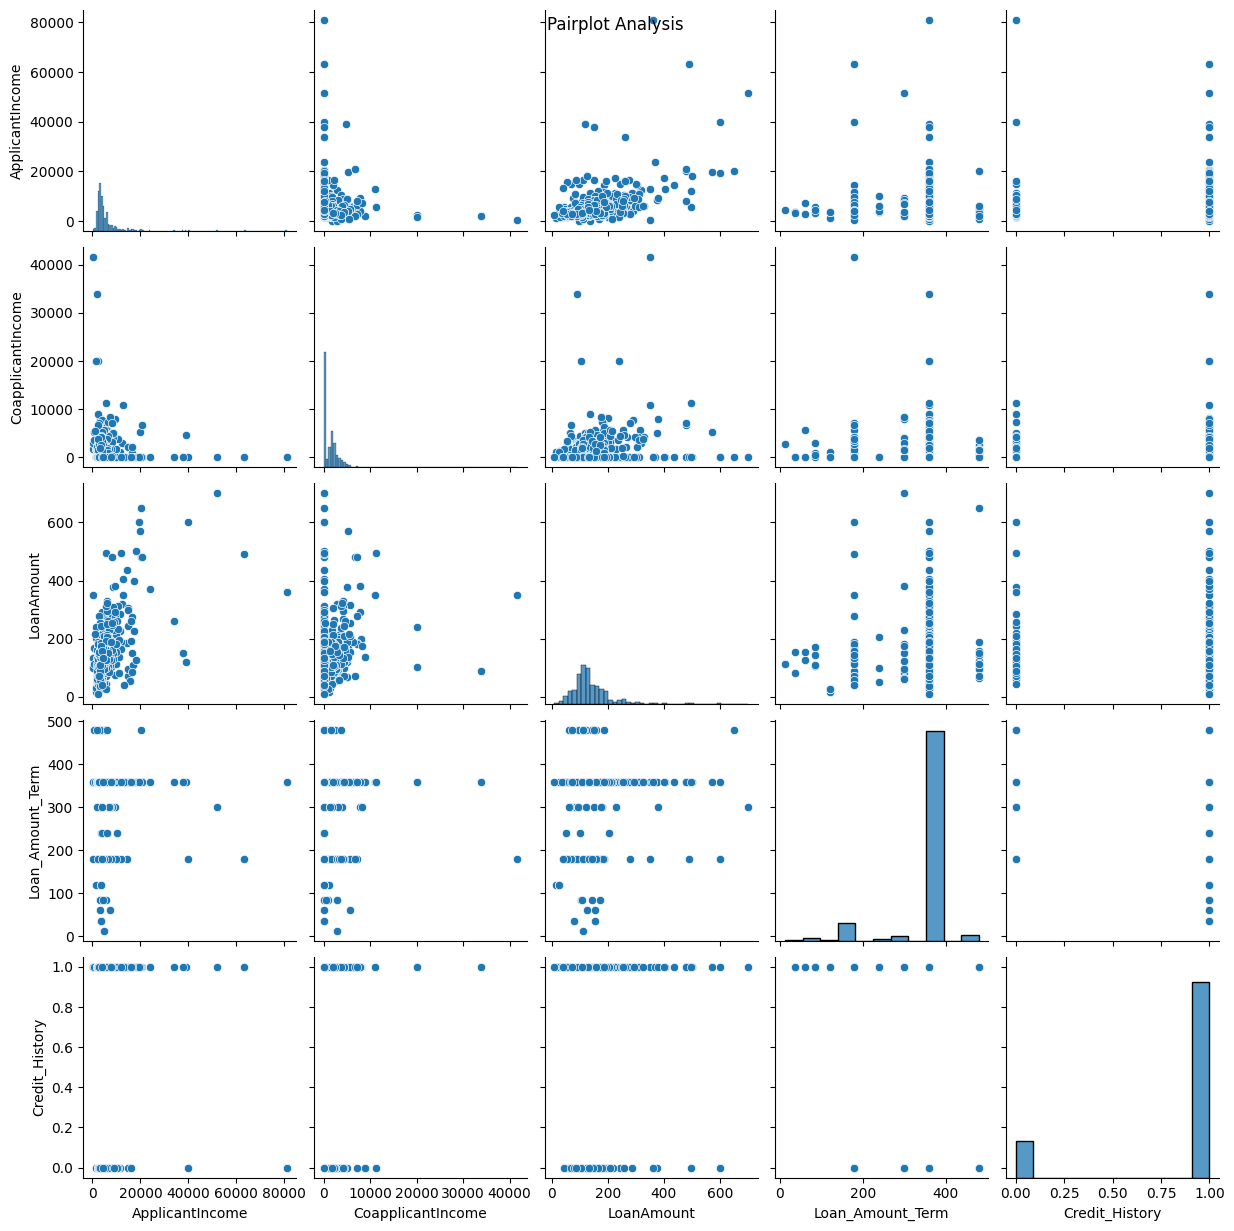

In [308]:
# Show Pairplot analysis
sns.pairplot(num_cols)
plt.suptitle('Pairplot Analysis')
plt.show()

Most feature have a right-skewed. They have more small values than large values.

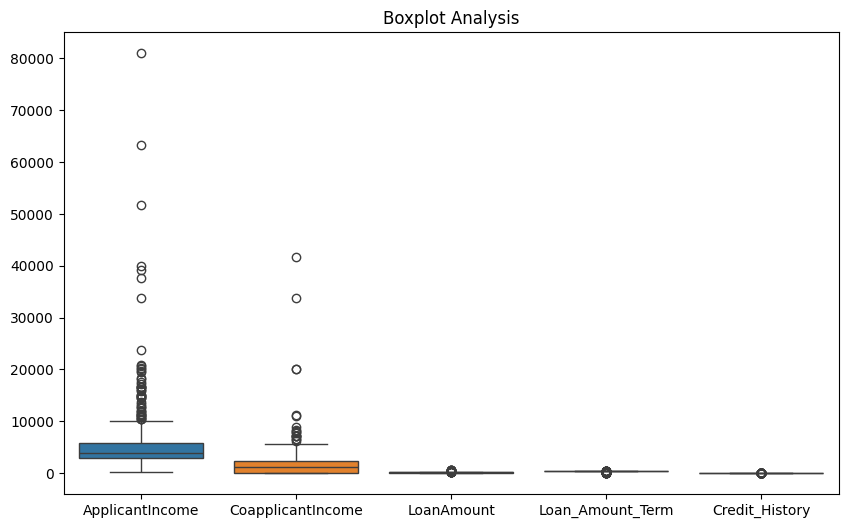

In [309]:
# Show Outliers analysis
plt.figure(figsize=(10,6))
sns.boxplot(num_cols)
plt.title('Boxplot Analysis')
plt.show()

### 2.2 Univariate Analysis 

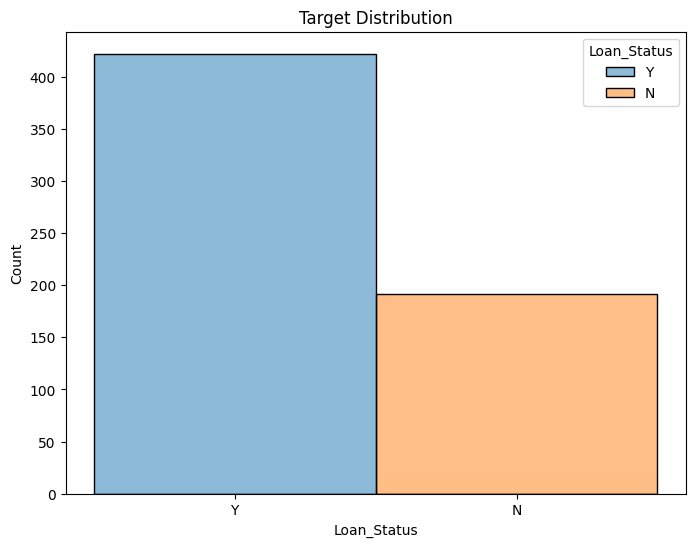

In [310]:
# Show the trget distribution using histplot
plt.figure(figsize=(8, 6))
sns.histplot(data=loan_train, x='Loan_Status', hue='Loan_Status')
plt.title('Target Distribution')
plt.show()

we can conclude that target has an imbalance data. Where applicant with status Yes/Approved is more than No.

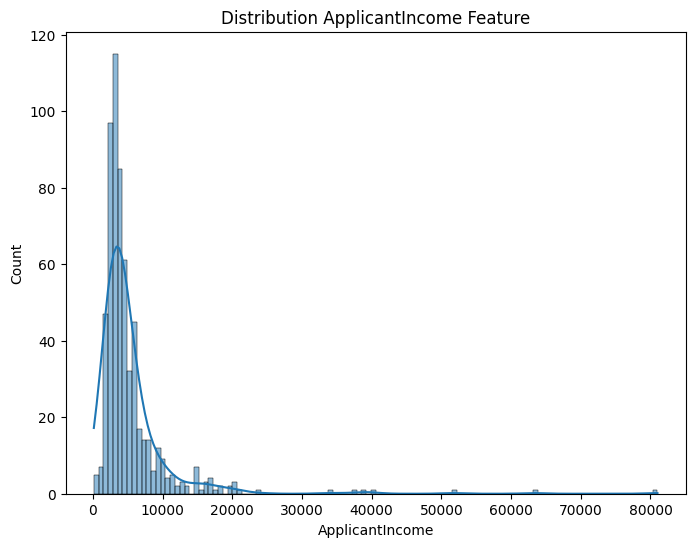

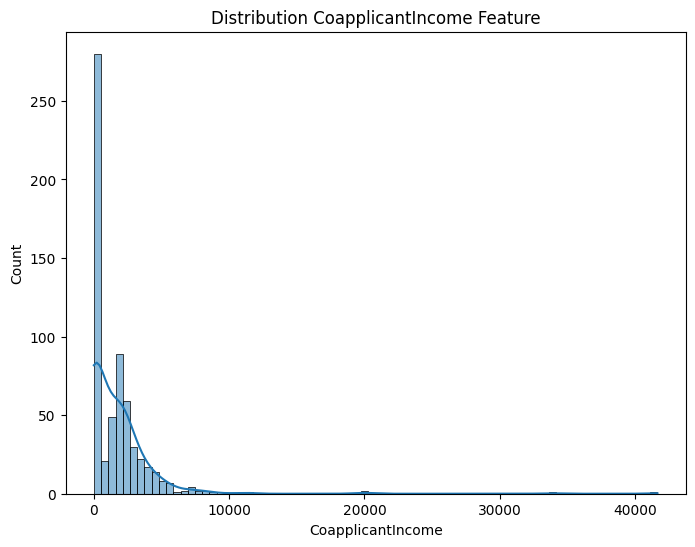

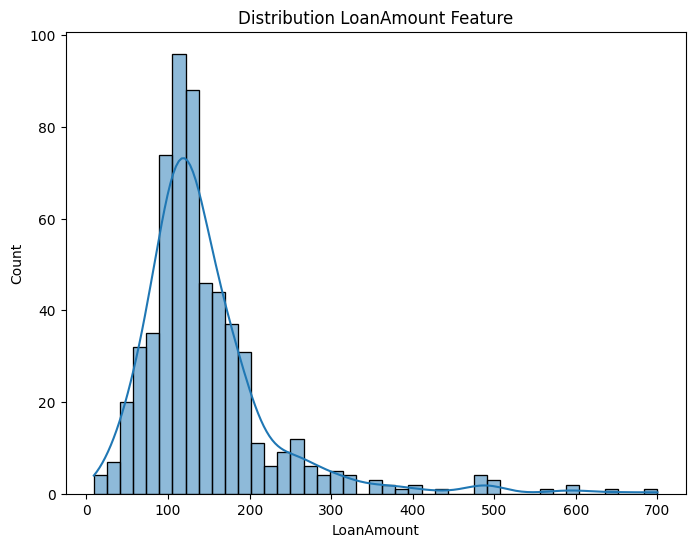

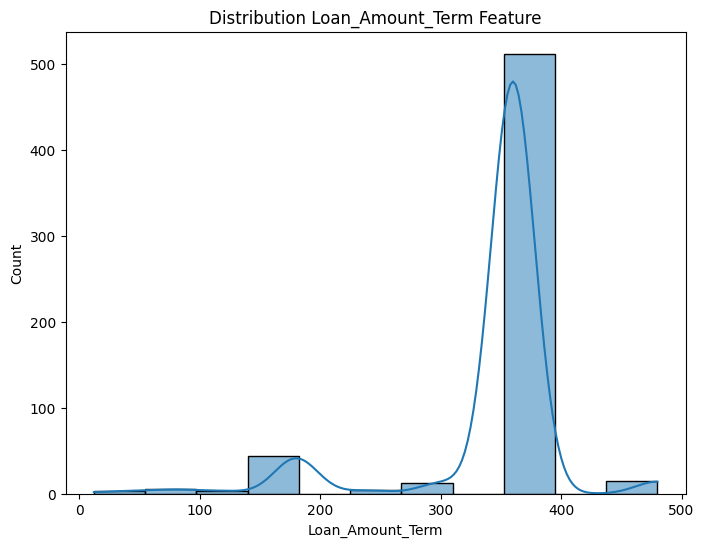

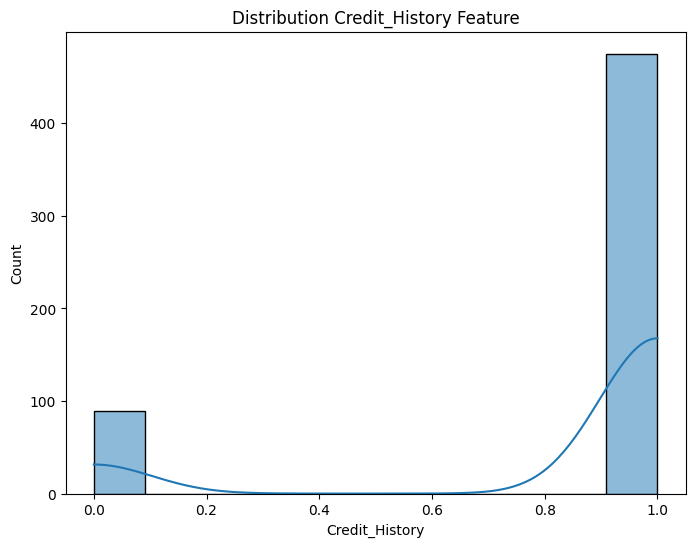

In [311]:
# Show numerical features distribution
for col in num_cols:
    plt.figure(figsize=(8, 6))
    sns.histplot(data=num_cols, x=col, kde=True)
    plt.title(f'Distribution {col} Feature')
    plt.show()

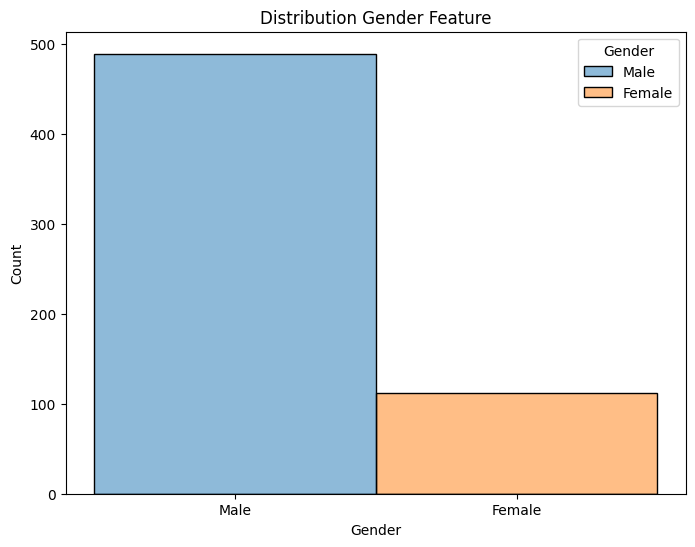

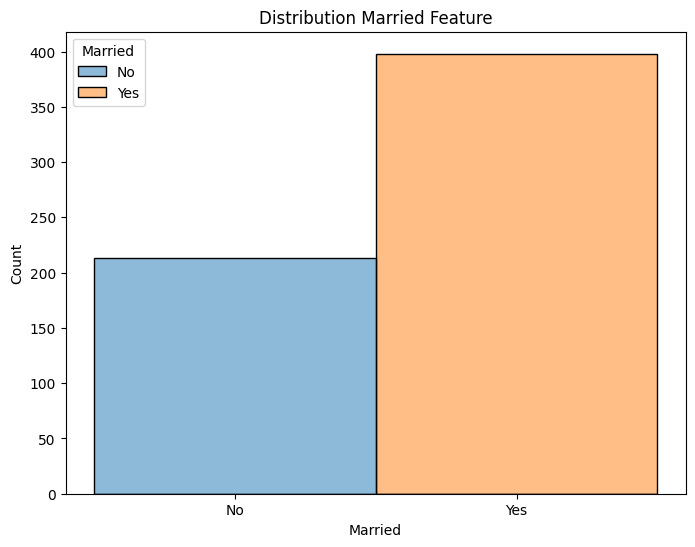

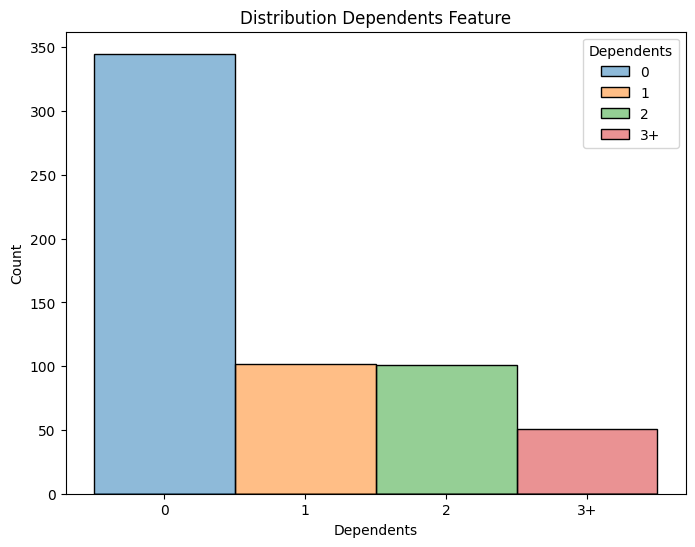

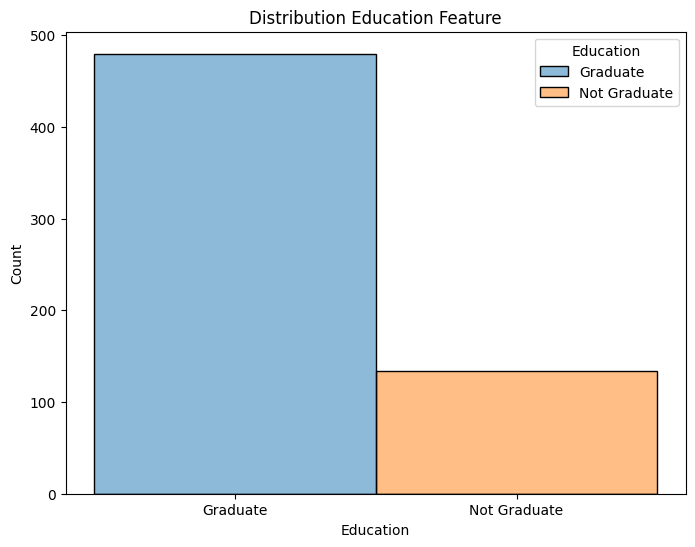

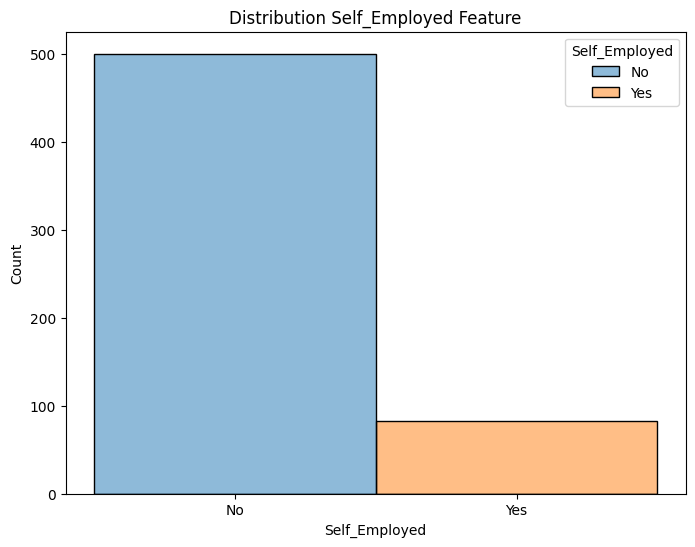

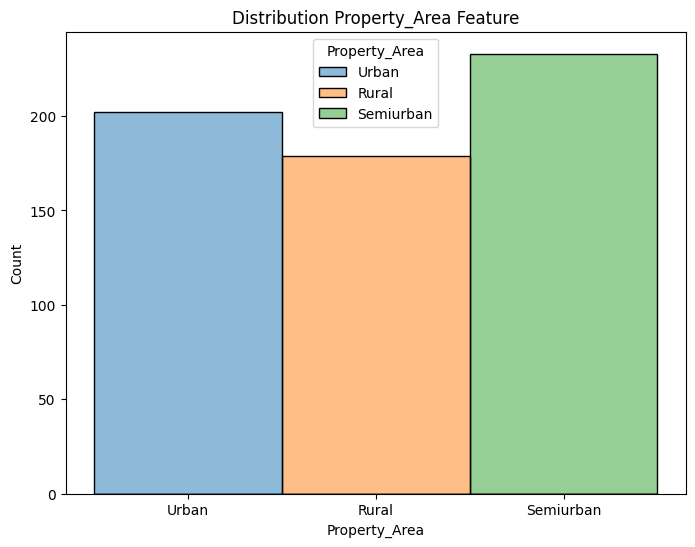

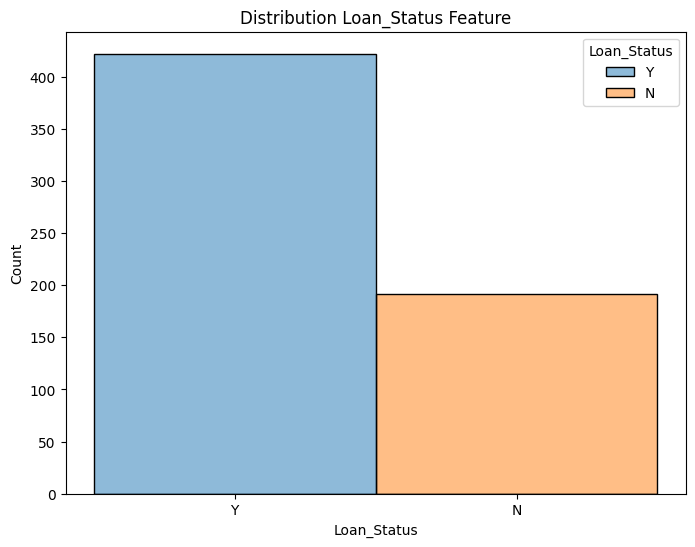

In [312]:
# Show categorical feature distribution 
for col in cat_cols:
    plt.figure(figsize=(8, 6))
    sns.histplot(cat_cols, x=col, hue=col)
    plt.title(f'Distribution {col} Feature')
    plt.show()

### 2.3 Bivariate Analysis

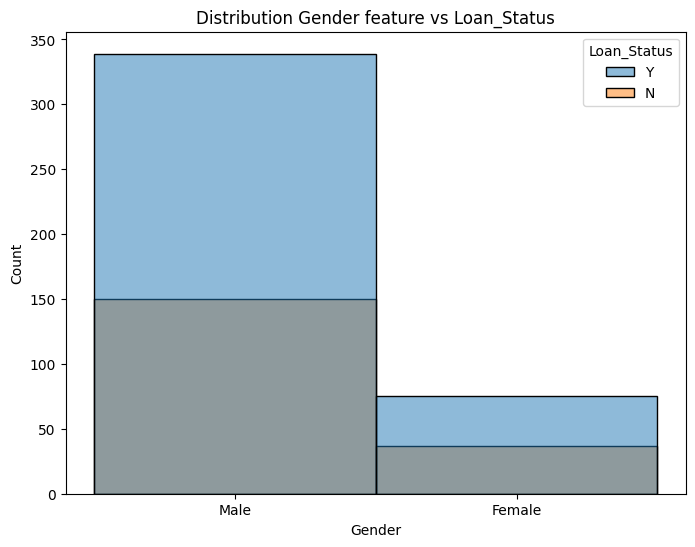

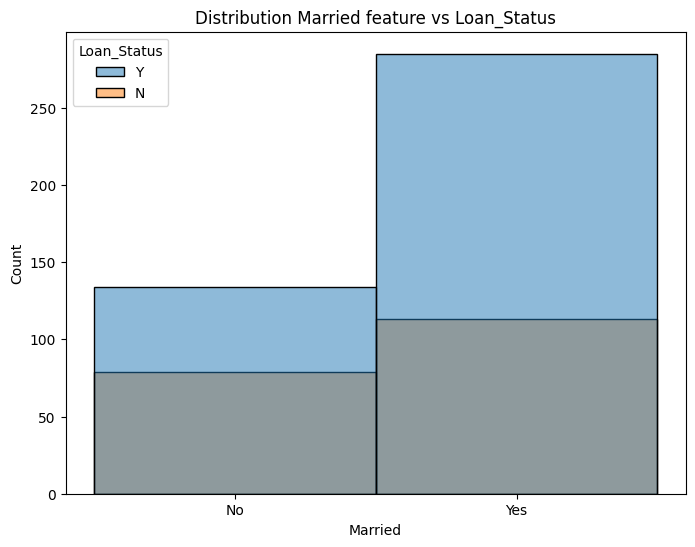

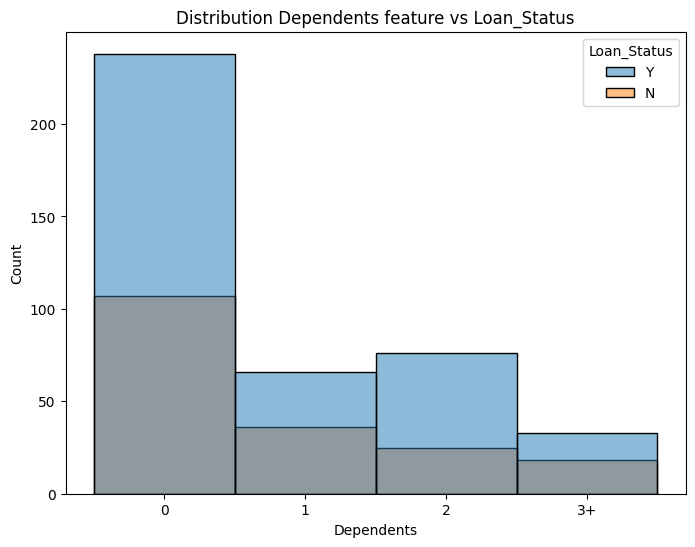

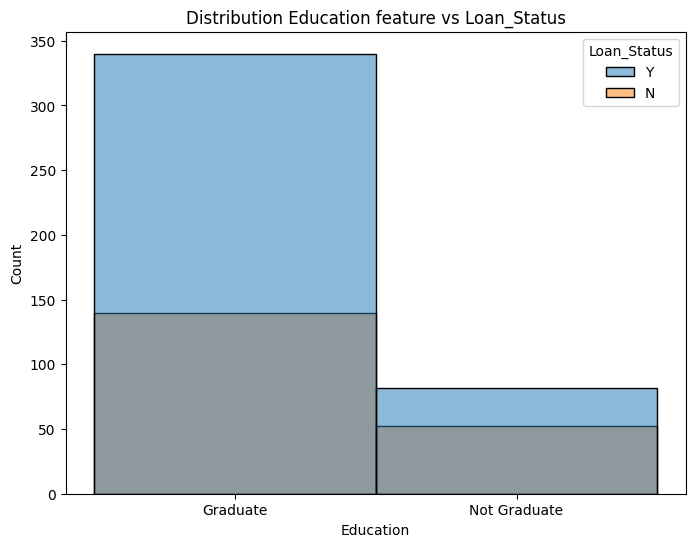

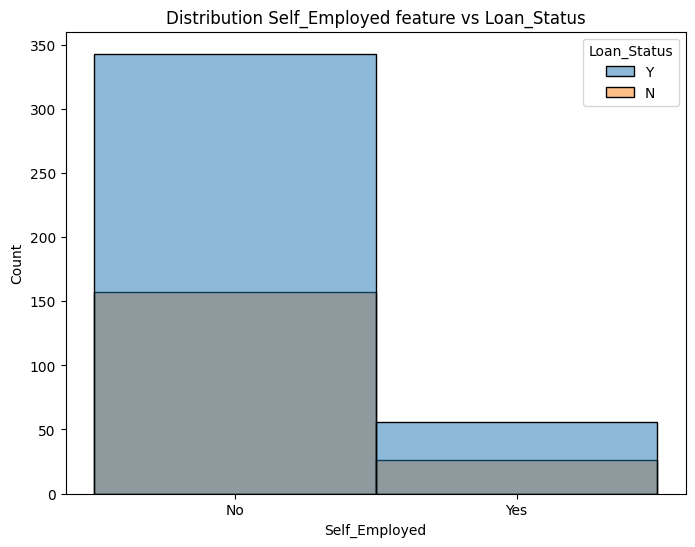

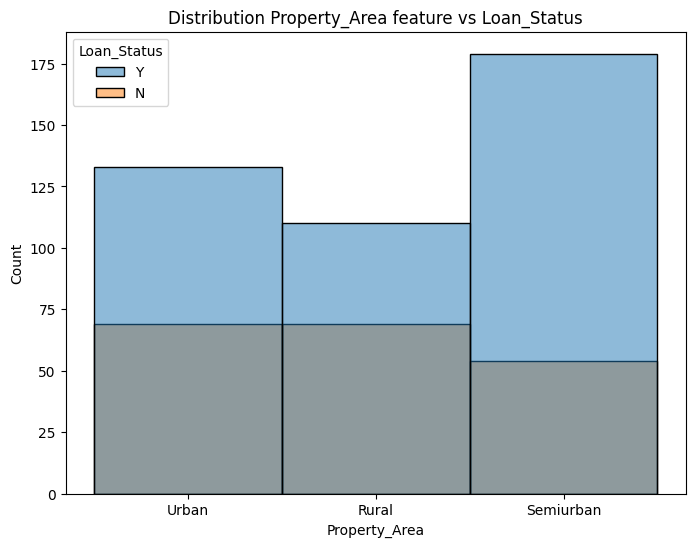

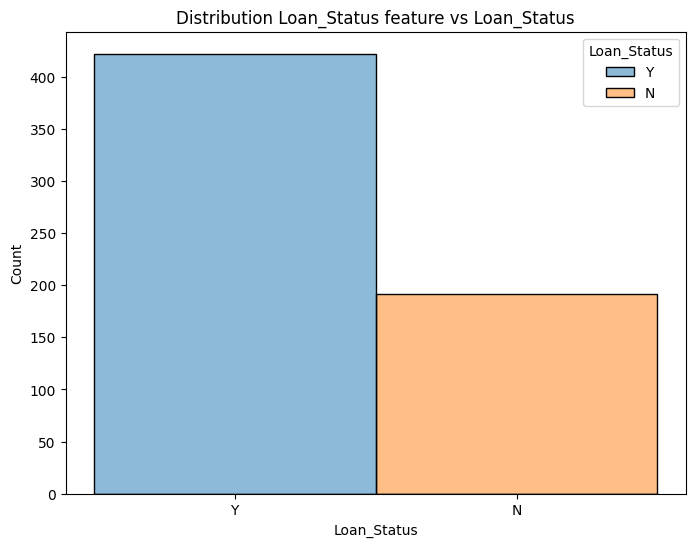

In [313]:
# Show distribution independent features vs target
for col in cat_cols:
    plt.figure(figsize=(8, 6))
    sns.histplot(data=cat_cols, x=col, hue='Loan_Status')
    plt.title(f'Distribution {col} feature vs Loan_Status')
    plt.show()

## 3. Data Preparation


In [314]:
# Handling outlier using log transformation
for col in num_cols:
    num_cols[col] = np.log1p(num_cols[col])

In [315]:
# Show statistical summary from num_cols
num_cols.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.000000,564.000000
mean,8.341510,4.290129,4.866325,5.804626,0.583768
std,0.645035,3.875873,0.499861,0.313126,0.252914
min,5.017280,0.000000,2.302585,2.564949,0.000000
25%,7.965024,0.000000,4.615121,5.888878,0.693147
50%,8.246303,7.081125,4.859812,5.888878,0.693147
75%,8.664922,7.739897,5.129899,5.888878,0.693147
max,11.302217,10.637489,6.552508,6.175867,0.693147


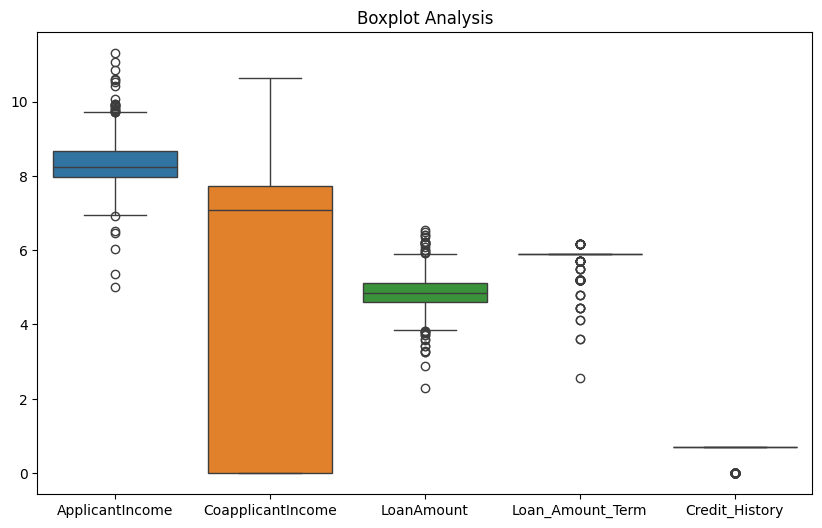

In [316]:
# Show Outliers analysis
plt.figure(figsize=(10,6))
sns.boxplot(num_cols)
plt.title('Boxplot Analysis')
plt.show()

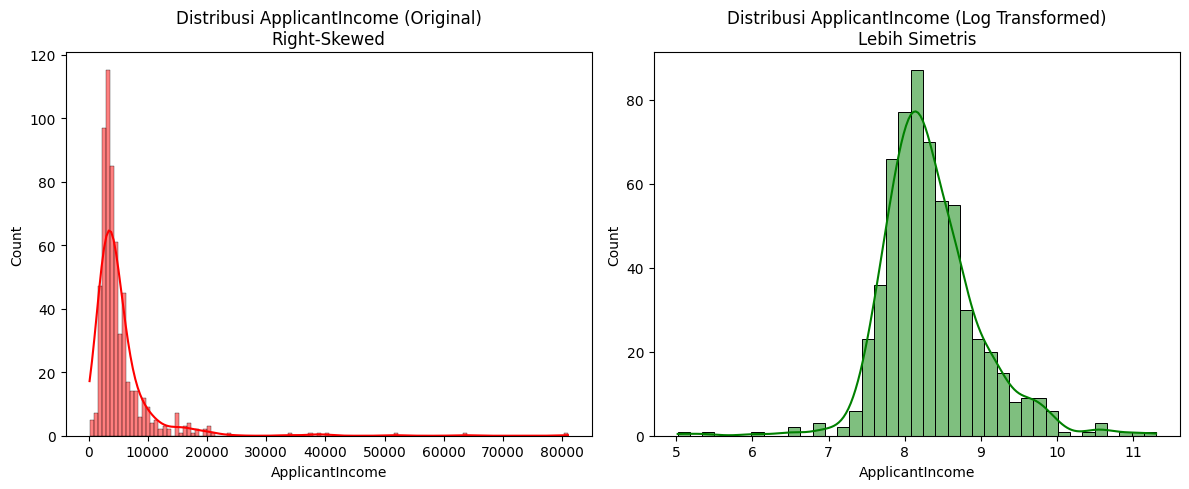

In [368]:
# Visualization
plt.figure(figsize=(12, 5))

# Sebelum Log
plt.subplot(1, 2, 1)
sns.histplot(loan_train['ApplicantIncome'], kde=True, color='red')
plt.title('Distribusi ApplicantIncome (Original)\nRight-Skewed')

# Sesudah Log 
plt.subplot(1, 2, 2)
sns.histplot(num_cols['ApplicantIncome'], kde=True, color='green')
plt.title('Distribusi ApplicantIncome (Log Transformed)\nLebih Simetris')

plt.tight_layout()
plt.show()

### 3.2 Handling Missing Values

In [317]:
# Show number of missing values in numerical & categorical columns
print('\nNumber of missing values in numerical columns:\n', num_cols.isnull().sum())
print('\nNumber of missing values in categorical columns:\n', cat_cols.isnull().sum())


Number of missing values in numerical columns:
 ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
dtype: int64

Number of missing values in categorical columns:
 Gender           13
Married           3
Dependents       15
Education         0
Self_Employed    32
Property_Area     0
Loan_Status       0
dtype: int64


In [318]:
# Show number of missing values in numerical & categorical columns
print('\nNumber of missing values in numerical columns:\n', num_cols.isnull().sum())
print('\nNumber of missing values in categorical columns:\n', cat_cols.isnull().sum())


Number of missing values in numerical columns:
 ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
dtype: int64

Number of missing values in categorical columns:
 Gender           13
Married           3
Dependents       15
Education         0
Self_Employed    32
Property_Area     0
Loan_Status       0
dtype: int64


In [319]:
# Handling missing values using modus
features = ['Gender', 'Married', 'Dependents', 'Self_Employed', 'Credit_History']
for col in features:
    loan_train[col] = loan_train[col].fillna(loan_train[col].mode()[0])
    
print('\nNumber of missing values in numerical columns:', loan_train.select_dtypes(include=['int64','float64']).isnull().sum().sum())
print('\nNumber of missing values in categorical columns:', loan_train.select_dtypes(include=['object','category']).isnull().sum().sum())


Number of missing values in numerical columns: 36

Number of missing values in categorical columns: 0


In [320]:
# Handling missing values with mean
features = ['LoanAmount', 'Loan_Amount_Term']
for col in features:
    loan_train[col] = loan_train[col].fillna(loan_train[col].mean())
print('\nNumber of missing values:', loan_train.isnull().sum().sum())


Number of missing values: 0


### 3.3 Encode Categorical Features

In [321]:
# Show unique values categorical features
cat_cols.columns

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'Property_Area', 'Loan_Status'],
      dtype='object')

In [322]:
# Encoding Categorical Feature
label_mapping = {}

col_str = loan_train.select_dtypes(include=['object', 'category'])

for col in col_str:
    codes, uniques = pd.factorize(loan_train[col])
    loan_train[col] = codes
    
    label_mapping[col] = uniques

for col, labels in label_mapping.items():
    print(f"Kolom: {col}")
    for i, label in enumerate(labels):
        print(f"  {i} -> {label}")
    print("-" * 20)


Kolom: Gender
  0 -> Male
  1 -> Female
--------------------
Kolom: Married
  0 -> No
  1 -> Yes
--------------------
Kolom: Dependents
  0 -> 0
  1 -> 1
  2 -> 2
  3 -> 3+
--------------------
Kolom: Education
  0 -> Graduate
  1 -> Not Graduate
--------------------
Kolom: Self_Employed
  0 -> No
  1 -> Yes
--------------------
Kolom: Property_Area
  0 -> Urban
  1 -> Rural
  2 -> Semiurban
--------------------
Kolom: Loan_Status
  0 -> Y
  1 -> N
--------------------


In [323]:
def get_label_info(mapping_dict, col_name):
    if col_name in mapping_dict:
        print(f"Pemetaan untuk kolom '{col_name}':")
        for i, label in enumerate(mapping_dict[col_name]):
            print(f"  {i} : {label}")
    else:
        print(f"Kolom '{col_name}' tidak ditemukan dalam mapping.")

In [324]:
get_label_info(label_mapping, 'Self_Employed')

Pemetaan untuk kolom 'Self_Employed':
  0 : No
  1 : Yes


In [325]:
# Show dtypes after encoding
loan_train.dtypes

Gender                 int64
Married                int64
Dependents             int64
Education              int64
Self_Employed          int64
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area          int64
Loan_Status            int64
dtype: object

### 3.4 Independent & Dependent Features

In [326]:
# Define Independent & Dependent Variables
X_before = loan_train.drop(['Loan_Status'], axis=1)
y = loan_train['Loan_Status']

### 3.5 Feature Scalling

In [327]:
# # Standarization
X = (X_before - X_before.mean()) / X_before.std()


## 4. Model 

### 4.1 Split Data Train & Data Validation

In [328]:
# Split data using stratified split
def split_data(X, y, size=0.8):
    np.random.seed(42)

    x_train, x_val = [], []
    y_train, y_val = [], []

    for class_values in np.unique(y):
        class_idx = np.where(y == class_values)[0]

        idx = np.random.permutation(class_idx)
        split = int(len(idx) * size)

        x_train.append(X.iloc[idx[:split]])        
        x_val.append(X.iloc[idx[split:]])        
        y_train.append(y.iloc[idx[:split]])        
        y_val.append(y.iloc[idx[split:]])

    X_train = pd.concat(x_train).reset_index(drop=True)
    X_val = pd.concat(x_val).reset_index(drop=True)
    y_train = pd.concat(y_train).reset_index(drop=True)
    y_val = pd.concat(y_val).reset_index(drop=True)

    return X_train, X_val, y_train, y_val

In [329]:
# Call the split function
X_train, X_val, y_train, y_val = split_data(X, y)

In [330]:
# Shape of data train & data vl
print(X_train.shape)
print(X_val.shape)
print(y_train.shape)
print(y_val.shape)

(490, 11)
(124, 11)
(490,)
(124,)


### 4.2 Implementation K - Nearest Neighbours Algoritm

In [331]:
# KNN class
class KNN:
    def __init__(self, k, p):
        self.k = k
        self.p = p
    
    def train(self, X, y):
        self.X_train = X
        self.y_train = y

    def distance(self, x1, x2):
        if self.p == 1:
            return np.sum(np.abs(x1 - x2))
        else:
            return np.sqrt(np.sum((x1 - x2)**2))
    
    def predict(self, X):
        y_pred = [self._predict(x) for x in X]
        return np.array(y_pred)

    def _predict(self, x):
        distance_i = [self.distance(x, X_train) for X_train in self.X_train]
        best_k = np.argsort(distance_i)[:self.k]
        label_k = [self.y_train[i] for i in best_k]
        result = max(set(label_k), key=label_k.count)
        return result

### 4.4 Resampling Data

#### 4.4.1 SMOTE Technique

In [332]:
# using SMOTE technique
def SMOTE(X, y, k=5):
    np.random.seed(42)

    counts = y.value_counts()
    minority_class = counts.idxmin()

    X_np = X.values
    y_np = y.values

    minority_X = X_np[y_np == minority_class]
    n_synthethic = counts.max() - counts.min()

    synthethic_samples = []

    for _ in range(n_synthethic):
        idx = np.random.randint(0, len(minority_X))
        sample = minority_X[idx]

        distances = np.sqrt(np.sum((minority_X - sample)**2, axis=1))
        nn_indicies = np.argsort(distances)[1:k+1]
        nn_idx = np.random.choice(nn_indicies)
        neighboor = minority_X[nn_idx]

        gap = np.random.rand()
        synthethic_samples.append(sample + gap * (neighboor - sample))

    X_balanced = np.vstack((X_np, synthethic_samples))
    y_balanced = np.hstack((y_np, np.full(n_synthethic, minority_class)))
    shuffle_idx = np.random.permutation(len(y_balanced))
    
    X_smote = pd.DataFrame(X_balanced[shuffle_idx], columns=X.columns)
    y_smote = pd.Series(y_balanced[shuffle_idx], name=y.name)
    
    return X_smote, y_smote

In [333]:
# call the SMOTE function
majority_class = loan_train[loan_train['Loan_Status'] == 1]
minority_class = loan_train[loan_train['Loan_Status'] == 2]

X_train_smote, y_train_smote = SMOTE(X_train, y_train)

In [334]:
# Shape of X and y train
print(X_train_smote.shape)
print(y_train_smote.shape)

(674, 11)
(674,)


#### 4.4.2 Noise Injection Technique

In [335]:
# Noise injection's function
def noise_injection(X, y, noise_factor=0.1):
    np.random.seed(42)

    counts = y.value_counts()
    minority_class = counts.idxmin()

    X_np = X.values
    y_np = y.values

    minority_X = X_np[y_np == minority_class]
    n_synthetic = counts.max() - counts.min()

    indicies = np.random.choice(len(minority_X), n_synthetic, replace=True)
    base_sample = minority_X[indicies]

    std_devs = np.std(X_np, axis=0) * noise_factor
    noise = np.random.normal(0, std_devs, base_sample.shape)

    noisy_sample = base_sample + noise

    X_balanced = np.vstack((X_np, noisy_sample))
    y_balanced = np.hstack((y_np, np.full(n_synthetic, minority_class)))

    shuffle_idx = np.random.permutation(len(y_balanced))

    X_noise = pd.DataFrame(X_balanced[shuffle_idx], columns=X.columns)
    y_noise = pd.Series(y_balanced[shuffle_idx], name=y.name)

    return X_noise, y_noise

In [336]:
# call the noise injection function
X_train_noise, y_train_noise = noise_injection(X_train, y_train)

In [337]:
# Dimensional data of X and y train
print(X_train_noise.shape)
print(y_train_noise.shape)

(674, 11)
(674,)


C:\Users\Silmy\AppData\Local\Temp\ipykernel_3352\2094596041.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train, palette='Pastel1')
C:\Users\Silmy\AppData\Local\Temp\ipykernel_3352\2094596041.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train_noise, palette='Pastel2')


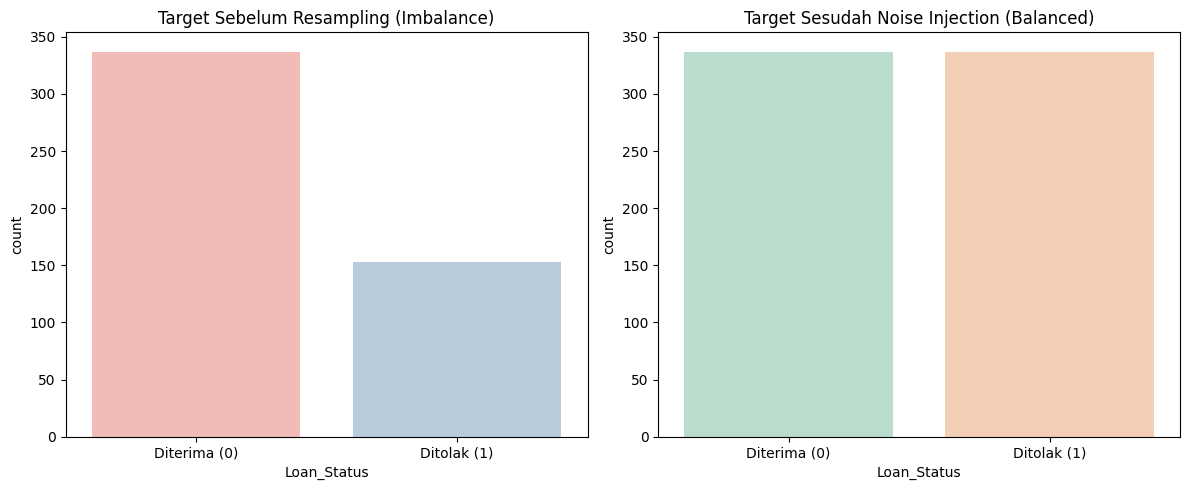

In [365]:
# Visualization dependent variabels
plt.figure(figsize=(12, 5))

# Sebelum Resampling
plt.subplot(1, 2, 1)
sns.countplot(x=y_train, palette='Pastel1')
plt.title('Target Sebelum Resampling (Imbalance)')
plt.xticks([0, 1], ['Diterima (0)', 'Ditolak (1)'])

# Sesudah Noise Injection
plt.subplot(1, 2, 2)
sns.countplot(x=y_train_noise, palette='Pastel2')
plt.title('Target Sesudah Noise Injection (Balanced)')
plt.xticks([0, 1], ['Diterima (0)', 'Ditolak (1)'])

plt.tight_layout()
plt.show()

### 4.5 Grid Search for the Best K and Distance Metric

In [338]:
# Function search k and distance Metric
def search_k(X_train, y_train, X_test):
    best_acc = 0
    best_k = {}
    
    for k in [3,5,7,9,11]:
        for p in [1,2]:
            model = KNN(k, p)
            model.train(X_train.values, y_train.values)
            pred = model.predict(X_test.values)
            acc = np.mean(pred == y_val.values)
    
            distance = 'manhattan' if p == 1 else 'euclidean'
            print(f'K: {k} - Distance: {distance} - Accuracy: {acc:.4f}')
    
            if acc > best_acc:
                best_acc = acc
                best_k = {'k':k, 'p':p}
    distance_label = 'maanhattan' if p == 1 else 'euclidean'
    print('Final')
    print(f'Best K: {best_k.get('k', 'N/A')} - Distance: {distance_label} - Accuracy: {best_acc:.4f}')

    return best_k

In [339]:
# Call the search besk k and distance metric without resampling
best_k_reguler = search_k(X_train, y_train, X_val)

K: 3 - Distance: manhattan - Accuracy: 0.7823
K: 3 - Distance: euclidean - Accuracy: 0.7661
K: 5 - Distance: manhattan - Accuracy: 0.8226
K: 5 - Distance: euclidean - Accuracy: 0.7984
K: 7 - Distance: manhattan - Accuracy: 0.8145
K: 7 - Distance: euclidean - Accuracy: 0.8145
K: 9 - Distance: manhattan - Accuracy: 0.8306
K: 9 - Distance: euclidean - Accuracy: 0.8226
K: 11 - Distance: manhattan - Accuracy: 0.8065
K: 11 - Distance: euclidean - Accuracy: 0.8145
Final
Best K: 9 - Distance: euclidean - Accuracy: 0.8306


In [340]:
# Call the search besk k and distance metric using SMOTE technique
best_k_smote = search_k(X_train_smote, y_train_smote, X_val)

K: 3 - Distance: manhattan - Accuracy: 0.7258
K: 3 - Distance: euclidean - Accuracy: 0.7258
K: 5 - Distance: manhattan - Accuracy: 0.7339
K: 5 - Distance: euclidean - Accuracy: 0.6694
K: 7 - Distance: manhattan - Accuracy: 0.7258
K: 7 - Distance: euclidean - Accuracy: 0.6452
K: 9 - Distance: manhattan - Accuracy: 0.7339
K: 9 - Distance: euclidean - Accuracy: 0.6774
K: 11 - Distance: manhattan - Accuracy: 0.7339
K: 11 - Distance: euclidean - Accuracy: 0.7097
Final
Best K: 5 - Distance: euclidean - Accuracy: 0.7339


In [341]:
# Call the search besk k and distance metric using Noise Injection technique
best_k_noise = search_k(X_train_noise, y_train_noise, X_val)

K: 3 - Distance: manhattan - Accuracy: 0.7500
K: 3 - Distance: euclidean - Accuracy: 0.7339
K: 5 - Distance: manhattan - Accuracy: 0.7661
K: 5 - Distance: euclidean - Accuracy: 0.7097
K: 7 - Distance: manhattan - Accuracy: 0.7984
K: 7 - Distance: euclidean - Accuracy: 0.6694
K: 9 - Distance: manhattan - Accuracy: 0.7742
K: 9 - Distance: euclidean - Accuracy: 0.6935
K: 11 - Distance: manhattan - Accuracy: 0.7500
K: 11 - Distance: euclidean - Accuracy: 0.7339
Final
Best K: 7 - Distance: euclidean - Accuracy: 0.7984


In [342]:
# Reguler
model = KNN(k=best_k_reguler.get('k'), p=best_k_reguler.get('p'))
model.train(X_train.values, y_train.values)

# SMOTE
model_smote = KNN(k=best_k_smote.get('k'), p=best_k_smote.get('p'))
model_smote.train(X_train_smote.values, y_train_smote.values)

# Noise
model_noise = KNN(k=best_k_noise.get('k'), p=best_k_noise.get('p'))
model_noise.train(X_train_noise.values, y_train_noise.values)

In [343]:
# Reguler
y_pred_train = model.predict(X_train.values)
y_pred_val = model.predict(X_val.values)

# SMOTE
y_pred_train_smote = model_smote.predict(X_train_smote.values)
y_pred_val_smote = model_smote.predict(X_val.values)

# Noise
y_pred_train_noise = model_noise.predict(X_train_noise.values)
y_pred_val_noise = model_noise.predict(X_val.values)


## 5. Evalution 







### 5.1 Evaluation Function

In [344]:
# Evaluation Function
def evaluate(y_true, y_pred, title='Train'):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    classes = np.unique(y_true)
    n_classes = len(classes)

    accuracy = np.mean(y_true == y_pred)
    precision = []
    recall = []
    f1 = []

    for i in classes:
        tp = np.sum((y_true == i) & (y_pred == i))
        fp = np.sum((y_true != i) & (y_pred == i))
        fn = np.sum((y_true == i) & (y_pred != i))

        p = tp / (tp + fp) if (tp + fp) > 0 else 0
        r = tp / (tp + fn) if (tp + fn) > 0 else 0
        f = 2 * (p * r) / (p + r) if (p + r) > 0 else 0

        precision.append(p)
        recall.append(r)
        f1.append(f)

    precision = np.mean(precision)
    recall = np.mean(recall)
    f1 = np.mean(f1)

    print(f'Hasil Evluasi {title}')
    print(f'Accuracy        : {accuracy:.4%}')
    print(f'Precision       : {precision:.4%}')
    print(f'Recall          : {recall:.4%}')
    print(f'F1              : {f1:.4%}')

### 5.2 SMOTE Data Evaluation

In [345]:
# Call the evaluation function for train data
evaluate(y_train_smote, y_pred_train_smote, title='Train SMOTE')

Hasil Evluasi Train SMOTE
Accuracy        : 86.0534%
Precision       : 86.0547%
Recall          : 86.0534%
F1              : 86.0533%


In [346]:
# Call the evaluation function for validation
evaluate(y_val, y_pred_val_smote, title='Validation SMOTE')

Hasil Evluasi Validation SMOTE
Accuracy        : 73.3871%
Precision       : 69.4251%
Recall          : 70.1810%
F1              : 69.7494%


### 5.3 Noise Injection Data Evaluation

In [347]:
# Call the evaluation function for data train 
evaluate(y_train_noise, y_pred_train_noise, title='Train Noise')

Hasil Evluasi Train Noise
Accuracy        : 83.5312%
Precision       : 84.4487%
Recall          : 83.5312%
F1              : 83.4208%


In [348]:
# Call the evaluation function for data validation
evaluate(y_val, y_pred_val_noise, title='Validation Noise')

Hasil Evluasi Validation Noise
Accuracy        : 79.8387%
Precision       : 76.9608%
Recall          : 74.8869%
F1              : 75.7339%


### 5.4 Reguler Data Evaluation

In [349]:
# Call the reguler evaluation function for train data
evaluate(y_train, y_pred_train)

Hasil Evluasi Train
Accuracy        : 80.6122%
Precision       : 84.6126%
Recall          : 70.2033%
F1              : 72.5975%


In [350]:
# Call the reguler evaluation function for validation data
evaluate(y_train, y_pred_train)

Hasil Evluasi Train
Accuracy        : 80.6122%
Precision       : 84.6126%
Recall          : 70.2033%
F1              : 72.5975%


### 5.5 Evaluation Using Normalization Technique

###  Regular Model

#### Training Results
- **Accuracy**  : 80.6789%
- **Precision** : 83.1166%
- **Recall**    : 70.5245%
- **F1-Score**  : 72.9210%

#### Testing Results
- **Accuracy**  : 83.5052%
- **Precision** : 82.9091%
- **Recall**    : 77.0149%
- **F1-Score**  : 78.9816%

---

###  SMOTE

#### Training Results (SMOTE)
- **Accuracy**  : 81.1321%
- **Precision** : 81.5928%
- **Recall**    : 81.1321%
- **F1-Score**  : 81.0630%

#### Testing Results (SMOTE)
- **Accuracy**  : 73.1959%
- **Precision** : 69.5811%
- **Recall**    : 71.3930%
- **F1-Score**  : 70.1468%

---

### Noise Injection

#### Training Results (Noise)
- **Accuracy**  : 81.5094%
- **Precision** : 82.9823%
- **Recall**    : 81.5094%
- **F1-Score**  : 81.3007%

#### Testing Results (Noise)
- **Accuracy**  : 78.3505%
- **Precision** : 74.9722%
- **Recall**    : 72.3632%
- **F1-Score**  : 73.3551%

In [358]:
# Confution Matrix Function
def confusion_matrix(y_train, y_pred_train, y_val, y_pred_val, title='Train'):
    classes = np.unique(y)
    n_classes = len(classes)

    fig, axes = plt.subplots(1, 2, figsize=(10,8))
    plt.suptitle(f'Evaluasi data {title}', fontsize=20, fontweight='bold')
    
    cm_train = np.zeros((n_classes, n_classes))
    for i, c_true in enumerate(classes):
        for j, c_pred in enumerate(classes):
            cm_train[i,j] = np.sum((y_train == c_true) * (y_pred_train == c_pred))
    sns.heatmap(cm_train, annot=True, fmt='.0f', cmap='Blues', ax=axes[0], cbar=False)
    
    cm_val = np.zeros((n_classes, n_classes))
    for a, a_true in enumerate(classes):
        for b, a_pred in enumerate(classes):
            cm_val[a,b] = np.sum((y_val == a_true) * (y_pred_val == a_pred))
    sns.heatmap(cm_val, annot=True, fmt='.0f', cmap='Blues', ax=axes[1], cbar=False)
    
    axes[0].set_ylabel('Aktual')
    axes[1].set_xlabel('Prediksi')
    plt.tight_layout()
    plt.show()

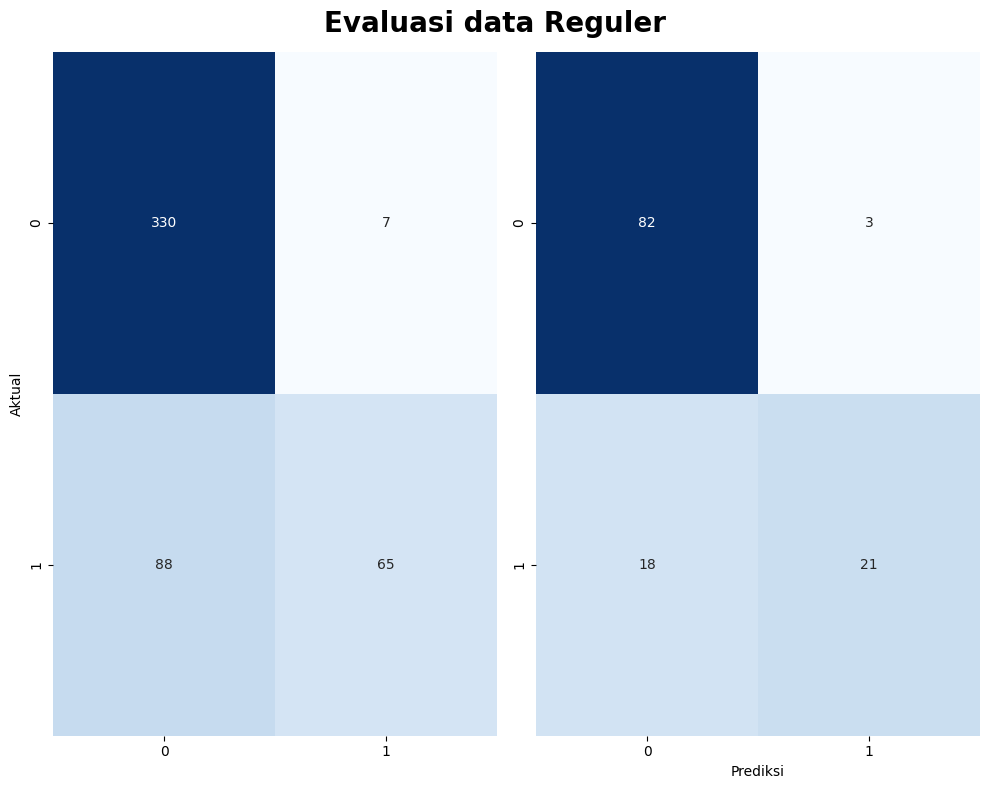

In [352]:
# Call confusion matrix visualization
confusion_matrix(y_train, y_pred_train, y_val, y_pred_val, title='Reguler')

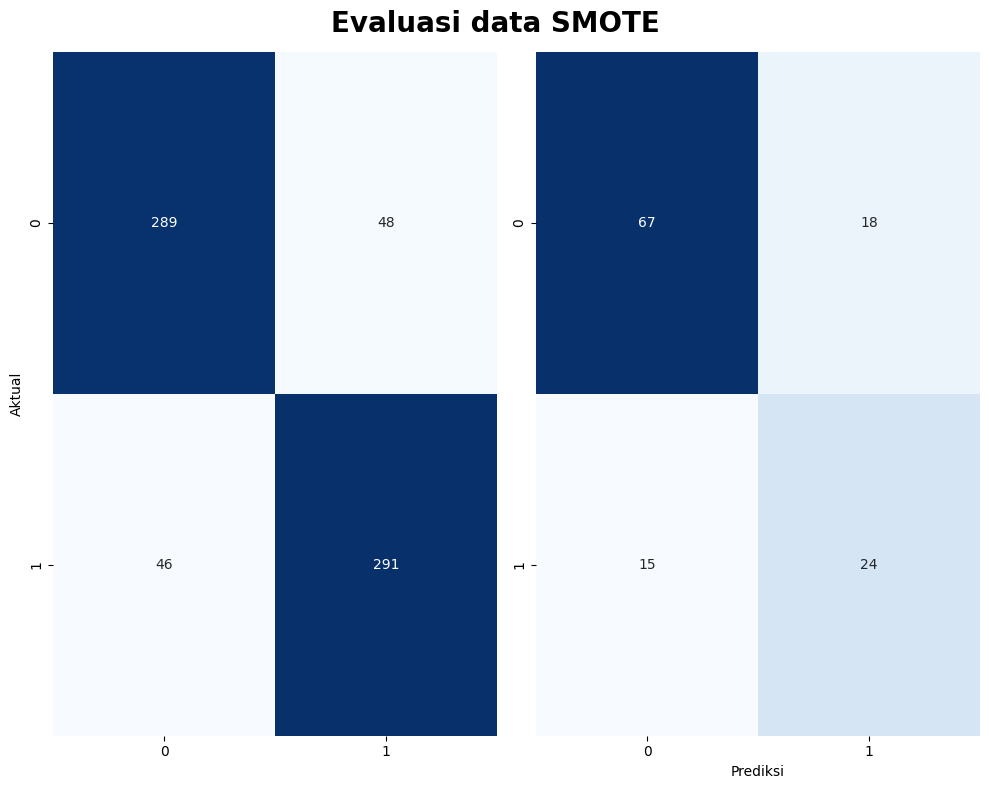

In [353]:
# Call the confution matrix function SMOTE technique
confusion_matrix(y_train_smote, y_pred_train_smote, y_val, y_pred_val_smote, title='SMOTE')

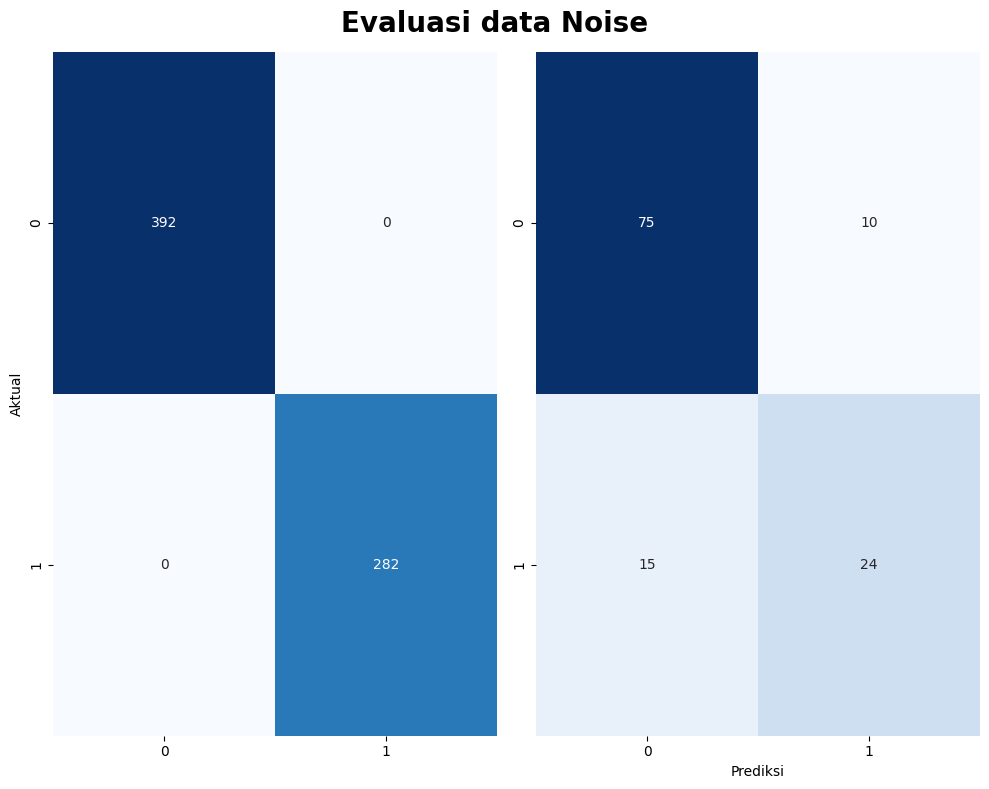

In [354]:
# Call the confusion matrix evaluation of Noise Techique
confusion_matrix(y_pred_train_noise, y_pred_train_noise, y_val, y_pred_val_noise, title='Noise')

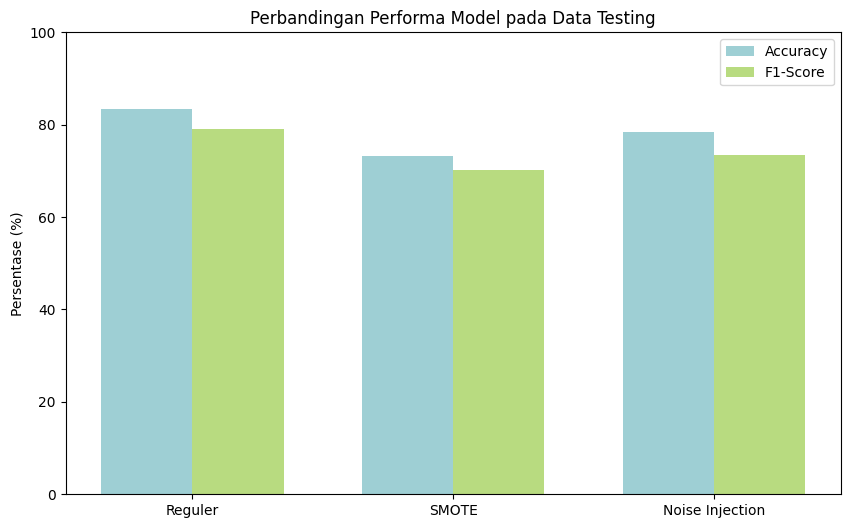

In [ ]:
models = ['Reguler', 'SMOTE', 'Noise Injection']
accuracy_scores = [83.50, 73.19, 78.35] 
f1_scores = [78.98, 70.14, 73.35]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width/2, accuracy_scores, width, label='Accuracy', color='#9ECFD4')
ax.bar(x + width/2, f1_scores, width, label='F1-Score', color='#B8DB80')

ax.set_ylabel('Persentase (%)')
ax.set_title('Perbandingan Performa Model pada Data Testing')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()

plt.ylim(0, 100)
plt.show()

## 7. Visualization

In [370]:
def plot_complete_knn(X, y, model, input_point=None, title="KNN Visualization", zoom=False):

    # Batas plot
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    
    # Meshgird
    h = 0.2
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid_points)
    Z = Z.reshape(xx.shape)
    
    plt.figure(figsize=(10, 7))
    
    # Visualisasi Decision Boundary
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='Pastel1')
    
    # ===== Plot Data Training =====
    classes = np.unique(y)
    for cls in classes:
        plt.scatter(X[y == cls, 0],
                    X[y == cls, 1],
                    label=f"Class {cls}",
                    edgecolor='k',
                    s=50)
    
    # Input Data Baru
    if input_point is not None:
        pred_label = model.predict([input_point])[0]
        
        distances = np.array([model.distance(input_point, x_t)
                              for x_t in model.X_train])
        k_indices = np.argsort(distances)[:model.k]
        
        # Titik input
        plt.scatter(input_point[0],
                    input_point[1],
                    marker='*',
                    s=300,
                    edgecolor='black',
                    label=f"Input (Pred: {pred_label})",
                    zorder=5)
        
        # Garis ke tetangga
        for idx in k_indices:
            plt.plot([input_point[0], X[idx, 0]],
                     [input_point[1], X[idx, 1]],
                     'k--', alpha=0.5)
            
            plt.scatter(X[idx, 0],
                        X[idx, 1],
                        facecolors='none',
                        edgecolors='black',
                        s=120,
                        linewidth=1.5)
        
        # Zoom Mode
        if zoom:
            all_x = [input_point[0]] + [X[i, 0] for i in k_indices]
            all_y = [input_point[1]] + [X[i, 1] for i in k_indices]
            margin = 0.5
            
            plt.xlim(min(all_x) - margin, max(all_x) + margin)
            plt.ylim(min(all_y) - margin, max(all_y) + margin)
    
    plt.title(f"{title}\nK={model.k}, p={model.p}")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.legend()
    plt.grid(alpha=0.2)
    plt.show()

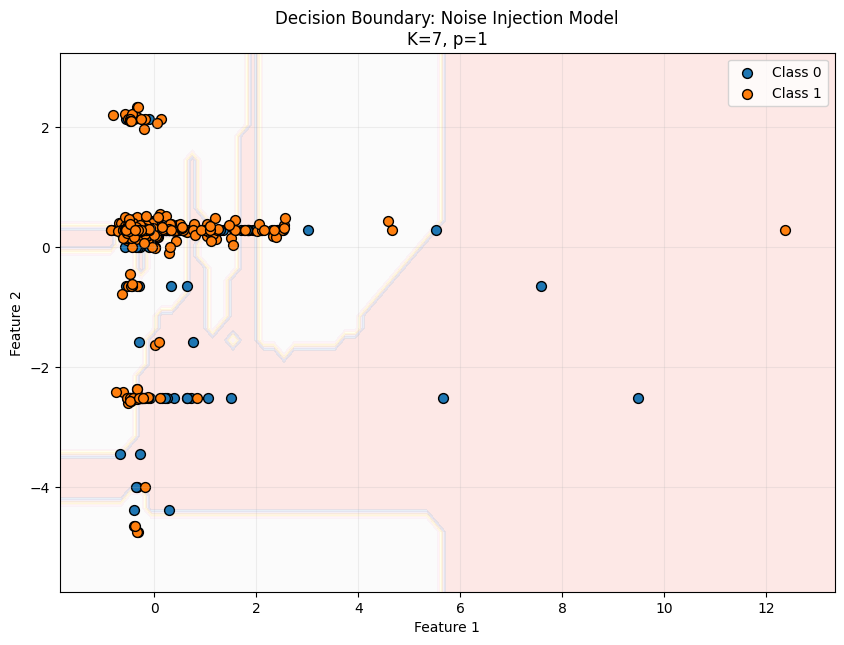

In [372]:
X_vis = X_train_noise.iloc[:, [5, 8]].values

y_vis = y_train_noise.values



model_vis = KNN(k=best_k_noise.get('k'), p=best_k_noise.get('p'))

model_vis.train(X_vis, y_vis)



plot_complete_knn(X_vis, y_vis, model_vis, title="Decision Boundary: Noise Injection Model", zoom=True)

## 7. GUI

In [373]:
feature = X.columns
n_feature = len(feature)

def submit():
    try:
        input_data = []
        for entry in entries:
            value = float(entry.get())
            input_data.append(value)

        input_df = pd.DataFrame([input_data], columns=feature)
        input_scaled = (input_df - X_before.mean()) / X_before.std()
        prediction = model_noise.predict(input_scaled.values)
        messagebox.showinfo('Hasil Prediksi', f'Tipe Pinjaman: {prediction}')
    except ValueError:
        messagebox.showerror('Input Error', 'Masukan Value Yang Benar')
        
root = tk.Tk()
root.configure(bg='#9ECFD4')
root.title('Prediksi Status Pinjaman')
entries = []

title_label = tk.Label(root, text='Prediksi Status Pinjaman', font=('Arial', 26, 'bold'), bg='#9ECFD4')
title_label.grid(row=0, column=0, columnspan=2, padx=25, pady=10)
for i, col in enumerate(feature):
    label = tk.Label(root, text=f'{col}:', bg='#9ECFD4')
    label.grid(row=i+1, column=0, padx=20, pady=5, sticky='w')

    entry = tk.Entry(bg='#7db0b5')
    entry.grid(row=i+1, column=1, padx=20, pady=5)
    entries.append(entry)

submit_btn = tk.Button(root, text='Prediksi', command=submit, bg='#B8DB80')
submit_btn.grid(row=n_feature+1, column=0, columnspan=2, pady=20, ipady=5)

root.mainloop()

## 8. Conclution

- Dataset cukup kotor dengan total missing values adalah 149. Dengan terdapat tipe data numerik, dan kategorikal. [Show Number of Missing Values Here.](#1-data-understanding)

- Target memiliki nilai immbalance. [Show Target Distribusion Here.](#22-univariate-analysis)

- Kebanyakan fitur numerik right-skewed. [Show Visualization Here.](#22-univariate-analysis)

#### **Kekurangan KNN dan Solusinya**:
1. KNN sensitif terhadap outlier. Sehingga kami atasi dengan teknik log transformation dan standarisasi.
2. KNN sensitif terhadap target immbalance. Sehingga kami resampling menggunakan teknik Noise Injection.

#### **Kelebihan KNN:**
1. Fleksibel


#### **Tambahan**
- Kami menggunakan teknik standarisasi dibanding normalisasi sebab hasil evaluasi standarisasi memiliki overall lebih baik. [Show Evaluation Here.](#5-evalution)
- Kami menggunakan teknik log transformation untuk mengatasi outlier, karena log hanya mengecilkan skala. Sehingga, tidak mengubah jauh dari data asli.
- Kami menggunakan Noise Injection, karena memiliki hasil kesalahan prediksi yang lebih sedikit dari teknik yang lain. [Show Evaluation Here.](#6-visualization)
- Model kami cukup baik dengan target immbalance, dimana model tidak terlalu overfit hanya selisih 4%. [Show Evaluation Here.](#53-noise-injection-data-evaluation)